### MLOps Assignment 2 : Design and implement an end-to-end MLOps pipeline for model building, artifact/image creation, packaging, containerization, and CI/CD-based deployment using open-source tools

### Use case : 

Binary image classification (Cats vs Dogs) for a pet adoption platform.

### Group ID: 82
### Group members

| Name           | Email                                       | Student ID   | Contribution |
|----------------|---------------------------------------------|--------------|--------------|
| JAIDEEP PALIT  | 2024aa05319@wilp.bits-pilani.ac.in          | 2024aa05319  | 100%         |
|  OMKAR ANIL KUMAR | 2024ac05308@wilp.bits-pilani.ac.in         | 2024ac05308 |100%|
|  PALLAB KUMAR GHOSHAL  | 2024ab05312@wilp.bits-pilani.ac.in         | 2024ab05312 |100%|
|PANKAJ KUMAR  |2024ab05026@wilp.bits-pilani.ac.in   |2024ab05026|100%|
|PRASANNA B|2024ab05310@wilp.bits-pilani.ac.in|2024ab05310|100%|

### Problem Statement

Design and implement an end-to-end MLOps pipeline for model building, artifact/image creation, packaging, containerization, and CI/CD-based deployment using open-source tools

### Dataset:
Title: Cats and Dogs classification dataset

Source: CATS and Dogs binary classification dataset from Kaggle - https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset



### Task 1: Data Acquisition, Preprocessing & Exploratory Data Analysis (EDA)

Obtain the dataset. Pre-process to 224x224 RGB images for standard CNNs. Perform EDA with professional visualizations (histograms, correlation heatmaps, class balance).

#### Import Libraries

In [1]:
!pip install -r ../requirements.txt

#### Download the Dataset

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
from preprocess.preprocess import download_dataset
data_dir=download_dataset(url="bhavikjikadara/dog-and-cat-classification-dataset",download_path="cats_and_dogs_classification_data")

Path to dataset files: /home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/data/raw/cats_and_dogs_classification_data


#### Exploratory Data Analysis (EDA)

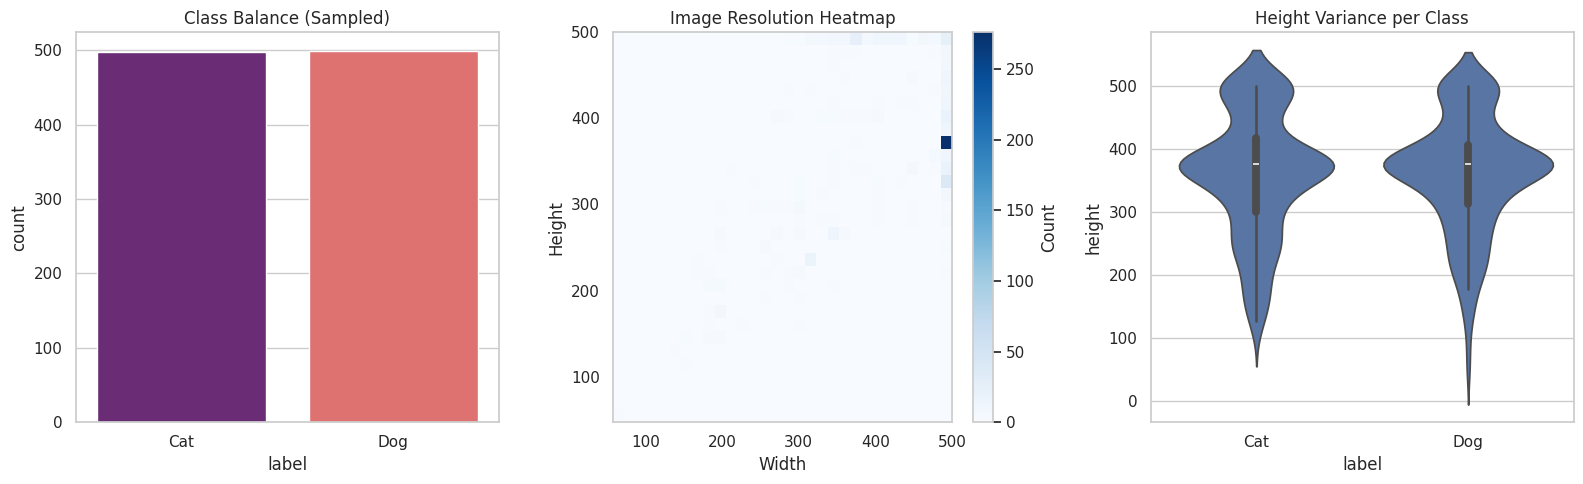

In [4]:
from preprocess.eda import eda_class_bal_image_res_channel_check
eda_class_bal_image_res_channel_check(data_dir=data_dir)


Analyzing Dog: 100%|██████████| 1000/1000 [00:00<00:00, 2779.40it/s]


<Figure size 1000x800 with 0 Axes>

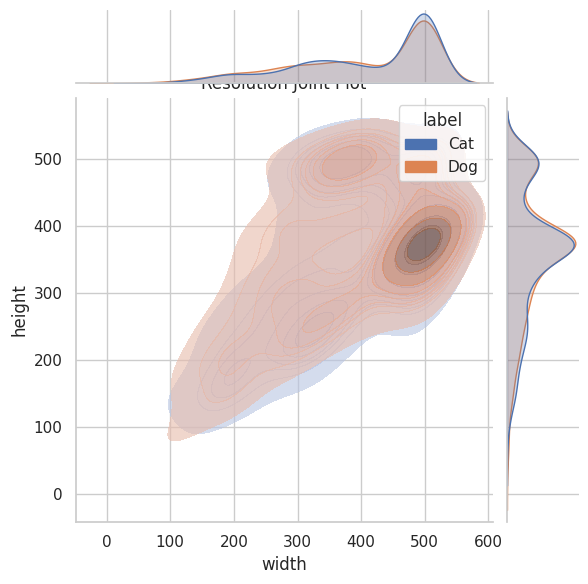

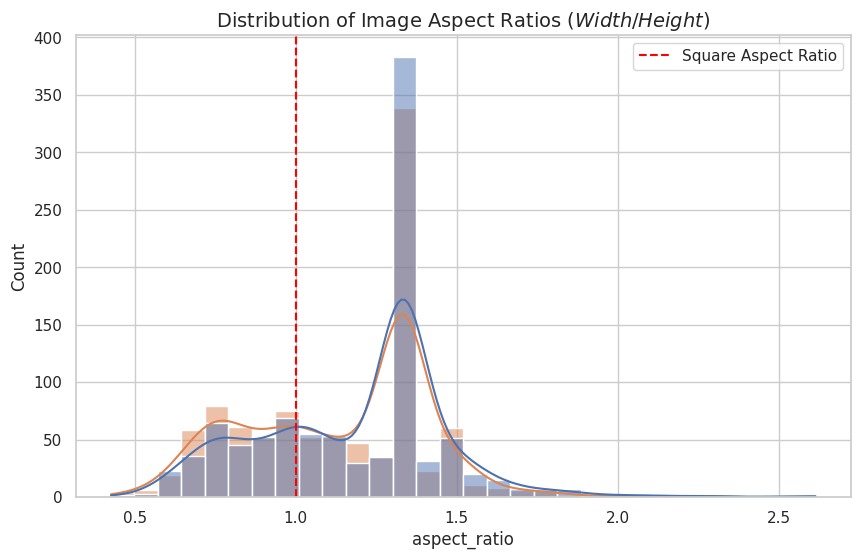

In [5]:
from preprocess.eda import perform_eda_res_disjoint_aspect_ratio
df_stats = perform_eda_res_disjoint_aspect_ratio(data_dir)


### Pre-process to 224x224 RGB images for standard CNNs
#### Train–Test Split

In [6]:
from preprocess.preprocess import pre_process_dataset
pre_process_dataset(data_dir=data_dir)

Processing Dog for test: 100%|██████████| 1250/1250 [00:00<00:00, 1457.73it/s]


✅ Dataset saved successfully at: /home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/data/preprocessed/preprocessed_cats_dogs_images


##### Data versioning with DVC

In [7]:
from preprocess.preprocess import data_versioning_with_dvc
data_versioning_with_dvc()


Running: dvc remote add -f origin s3://dvc
ERROR:
ERROR: configuration error - config file error: Not inside a DVC repo



SystemExit: 1

In [ ]:
from preprocess.preprocess import git_dvc_version
git_dvc_version()

### Model Building
Implement at least one baseline model (e.g., simple CNN or logistic regression on flattened pixels).
Save the trained model in a standard serialized format (e.g., .pkl, .pt, .h5).

##### Load dataset for training

In [8]:
from train.train_util import load_training_dataset
train_ds,val_ds=load_training_dataset()

Found 19953 files belonging to 2 classes.
Found 2498 files belonging to 2 classes.


In [9]:
from train.train_cnn import build_cnn,train_cnn
cnn_model=build_cnn()


In [10]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
history=train_cnn(model=cnn_model,train_ds=train_ds,val_ds=val_ds)


2026-02-17 21:57:43.565896: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 205520896 exceeds 10% of free system memory.
2026-02-17 21:57:43.622079: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 205520896 exceeds 10% of free system memory.
2026-02-17 21:57:43.660407: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 205520896 exceeds 10% of free system memory.
2026-02-17 21:57:44.419203: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 205520896 exceeds 10% of free system memory.
2026-02-17 21:57:44.480729: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 205520896 exceeds 10% of free system memory.


624/624 ━━━━━━━━━━━━━━━━━━━━ 635s 1s/step - accuracy: 0.6177 - loss: 0.6477 - val_accuracy: 0.5244 - val_loss: 0.8755


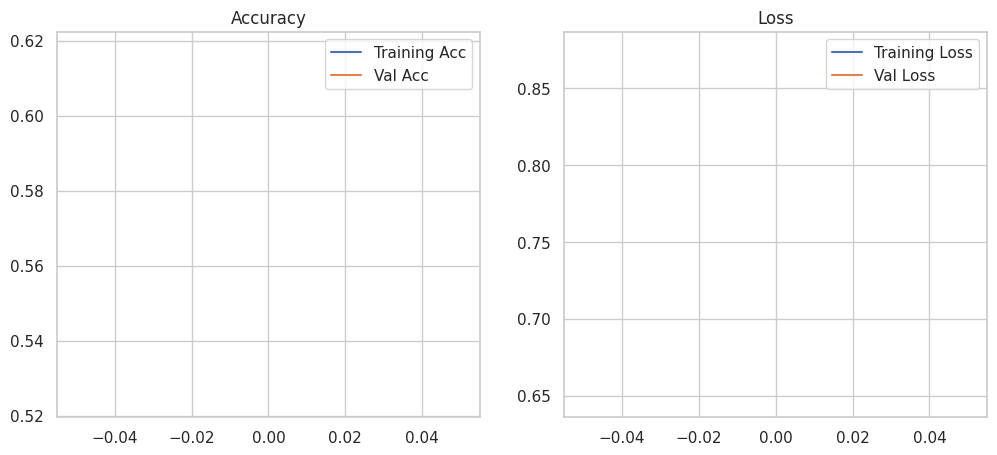

In [12]:
from train.train_cnn import plot_results
plot_results(history)

#### Evaluate Model with test dataset

In [3]:
from train.train_util import load_test_dataset
test_ds= load_test_dataset()

Found 2495 files belonging to 2 classes.


In [4]:
from evaluate.evaluate import evaluate_cnn
y_true, y_probs, y_pred=evaluate_cnn(model=cnn_model,test_ds=test_ds)

2026-02-17 22:21:28.158307: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


78/78 ━━━━━━━━━━━━━━━━━━━━ 18s 224ms/step


#### Confusion Matrix

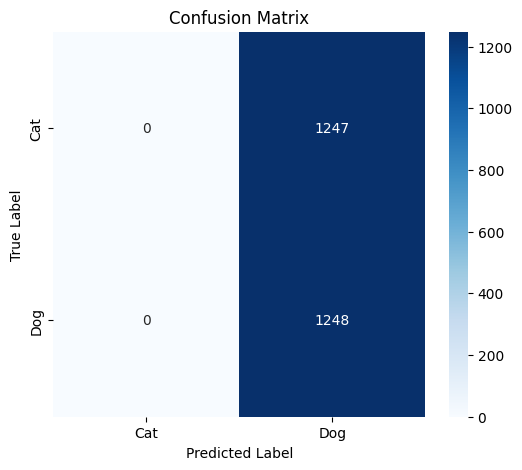

In [5]:
from evaluate.evaluate import plot_cnn_confusion_matrix
plot_cnn_confusion_matrix(y_true, y_pred)

#### ROC Curve and AUC

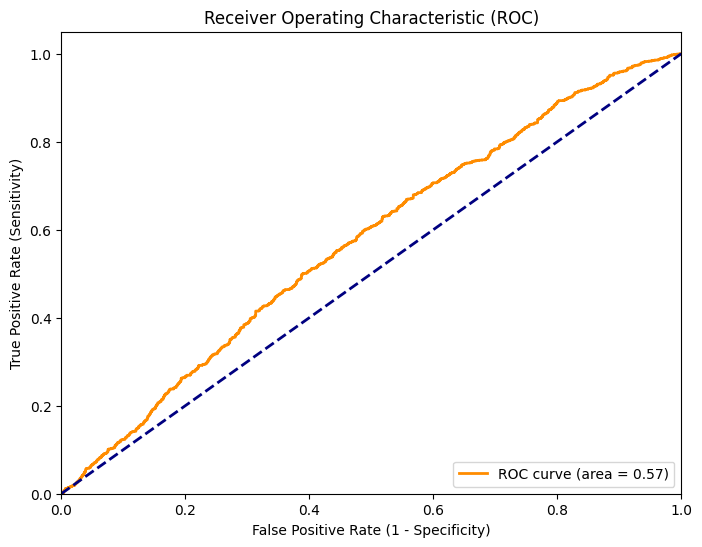

In [6]:
from evaluate.evaluate import plot_cnn_roc_curve
roc_auc=plot_cnn_roc_curve(y_true,y_probs)

#### Summary Metrics Table

------------------------------
Final Test Evaluation:
------------------------------
Accuracy:  0.5002
Precision: 0.5002
Recall:    1.0000
F1-Score:  0.6668
ROC-AUC:   0.5717
------------------------------


/home/jai/Desktop/code/mlops/bits-mtech-mlops-assignment-2/src/evaluate/evaluate.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=metrics_names, y=metrics_values, palette=palette)


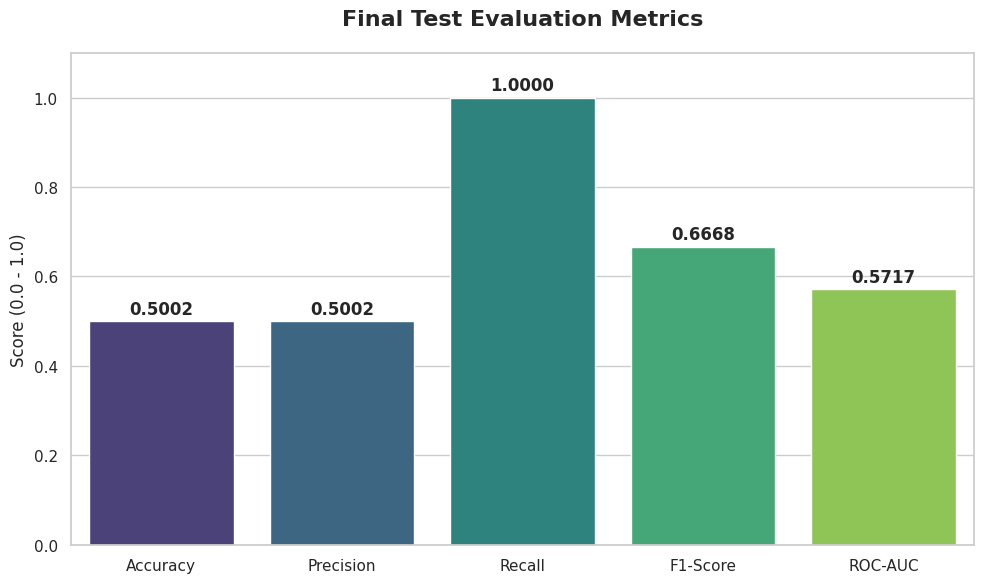

In [7]:
from evaluate.evaluate import plot_cnn_summary
metrics_values=plot_cnn_summary(y_true, y_pred, roc_auc)


### Experiment Tracking

Integrate MLflow (or a similar tool) for experiment tracking. Log parameters, metrics, artifacts, and plots for all runs.

#### Logging Plots as MLflow Artifacts

##### Initializing MLFlow

In [8]:
from evaluate.experiment_tracking import init_mlflow, mlflow_end_run

init_mlflow()
mlflow_end_run()

##### Log EDA plots

In [19]:
from evaluate.experiment_tracking import mlflow_eda
mlflow_eda()

##### CNN – MLflow Tracking

In [9]:
from evaluate.experiment_tracking import mlflow_cnn

mlflow_cnn(cnn_model=cnn_model,metrics=metrics_values)

Model summary logged to MLflow artifacts.
Logged CNN run


##### End MlFlow run

In [ ]:
from evaluate.experiment_tracking import mlflow_end_run
mlflow_end_run()

### Model Packaging & Reproducibility

##### Save CNN

In [ ]:
from train.train_util import save_model
save_model("cnn_model.pkl",cnn_model)
print("CNN model saved")

##### Load CNN Model (Reusability Check)

##### Reproducible Preprocessing Pipeline

In [1]:
from train.train_util import load_model
loaded_cnn_model=load_model("cnn_model.pkl")
print("CNN model loaded successfully")

CNN model loaded successfully


##### Perform Test Inference with Sample Data

In [10]:
from evaluate.evaluate import get_sample_test_data
cat_img, dog_img=get_sample_test_data()

##### CNN Prediction

In [ ]:
from evaluate.evaluate import get_prediction
import os

results = [("Actual Cat", cat_img), ("Actual Dog", dog_img)]

for actual, path in results:
    pred_label, conf, prob = get_prediction(cnn_model,path)
    print(f"--- Testing {actual} ---")
    print(f"File: {os.path.basename(path)}")
    print(f"Predicted Label: {pred_label}")
    print(f"Confidence:      {conf:.2%}")
    print(f"Raw Probability: {prob:.4f}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
--- Testing Actual Cat ---
File: 12189.jpg
Predicted Label: Dog
Confidence:      51.73%
Raw Probability: 0.5173

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
--- Testing Actual Dog ---
File: 12189.jpg
Predicted Label: Dog
Confidence:      51.80%
Raw Probability: 0.5180

